## Look for Extremes in Todays Salish Sea compared to the Climatology 2007-2025 ##

In [1]:
import cmocean.cm as cm
import copy
import datetime as dt
from matplotlib import colormaps as matplotlib_cm
from matplotlib import colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import netCDF4 as nc
from pathlib import Path
import xarray as xr

from salishsea_tools import visualisations, viz_tools
from ClimatologyFunctions import mymask, myravel, plot_how_extreme, read_climatology

import importlib

In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
plt.rcParams['font.size'] = 14
cm_haline = copy.copy(cm.haline)
cm_haline.set_bad('k')

In [4]:
mesh = xr.open_dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc')
tmask = mesh['tmask'][0]
deptht = mesh['gdept_1d'][0]

In [5]:
salishdir = Path('/results2/SalishSea/nowcast-green.202111/')

In [6]:
# set up dates
yearrange = [2007, 2025]
thisyear = 2026
today = dt.datetime(2026, 6, 21)

In [7]:
dirstring = today.strftime("%d%b%y").lower()
timestring = f'{today.year}{today.month:02d}{today.day:02d}'
datafilen = xr.open_dataset(salishdir / dirstring /f'SalishSea_1d_{timestring}_{timestring}_grid_T.nc')
datafilenb = xr.open_dataset(salishdir / dirstring / f'SalishSea_1d_{timestring}_{timestring}_biol_T.nc')
datafilenc = xr.open_dataset(salishdir / dirstring / f'SalishSea_1d_{timestring}_{timestring}_chem_T.nc')
datafilenv = xr.open_dataset(salishdir / dirstring / f'SalishSea_1h_{timestring}_{timestring}_grid_V.nc')
datafilenw = xr.open_dataset(salishdir / dirstring / f'SalishSea_1h_{timestring}_{timestring}_grid_W.nc')

In [8]:
nfields = 13
file4fields = ['', '', 'b', 'b', 'b', 'b', 'b', 'b', 'c', 'c', 'c', 'v', 'w']
fields = ['vosaline', 'votemper', 'nitrate', 'silicon', 'diatoms', 'flagellates', 'microzooplankton', 'particulate_organic_nitrogen',
          'dissolved_oxygen', 'dissolved_inorganic_carbon', 'turbidity', 'vomecrty', 'vert_eddy_diff']
nnames = ['salinity', 'temperature', 'nitrate', 'silicon', 'diatoms', 'nanoflagellates', 'Z1', 'PON',
          'oxygen', 'DIC','turbidity', 'NW velocity', 'v. diffusivity']
logit = [False, False, False, False, True, True, True, False, False, False, False, False, True]

In [9]:
# set up the subset of the spatial array to investigate
step = 5
slice_x = slice(0, 398, step)
slice_y = slice(0, 898, step)
slice_z = slice(0, 40, step)
st = 0  # time of day for hour files

In [10]:
nz, ny, nx = datafilen[fields[0]][0, slice_z, slice_y, slice_x].shape

In [11]:
history = np.zeros((nfields, yearrange[1] - yearrange[0] + 1, nz, ny, nx))
now = np.zeros_like(history[:, 0])

In [12]:
number_values = tmask[slice_z, slice_y, slice_x].sum(axis=2).sum(axis=1).values

In [13]:
for kf, field in enumerate(fields):
    print (field)
    if file4fields[kf] == '':
        now[kf] = datafilen[field][0, ::step, ::step, ::step]
    elif file4fields[kf] == 'b':
        now[kf] = datafilenb[field][0, ::step, ::step, ::step]
    elif file4fields[kf] == 'c':
        now[kf] = datafilenc[field][0, ::step, ::step, ::step]
    elif file4fields[kf] == 'v':
        now[kf] = datafilenv[field][:, ::step, ::step, ::step].mean(axis=0)
    elif file4fields[kf] == 'w':
        now[kf] = datafilenw[field][st, ::step, ::step, ::step]
    if logit[kf]:
        now[kf] = np.log(now[kf]+1e-5)
datafilen.close()
datafilenb.close()
datafilenc.close()
datafilenv.close()
datafilenw.close()

vosaline
votemper
nitrate
silicon
diatoms
flagellates
microzooplankton
particulate_organic_nitrogen
dissolved_oxygen
dissolved_inorganic_carbon
turbidity
vomecrty
vert_eddy_diff


In [14]:
history = read_climatology(yearrange, today, st, step, salishdir, dirstring, fields, file4fields, logit, history)

2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025


In [15]:
max_values = mymask(history.max(axis=1), np.arange(nz), nfields, tmask, step=step)
min_values = mymask(history.min(axis=1), np.arange(nz), nfields, tmask, step=step)
median_values = mymask(np.median(history, axis=1), np.arange(nz), nfields, tmask, step=step)
high_values = mymask(np.quantile(history, 0.75, axis=1), np.arange(nz), nfields, tmask, step=step)
low_values = mymask(np.quantile(history, 0.25, axis=1), np.arange(nz), nfields, tmask, step=step)

In [16]:
vsmall = (high_values - low_values) * 1e-3
min_mask = now < min_values - vsmall
max_mask = now > max_values + vsmall
lower_mask = now < median_values
upper_mask = now > median_values
low_mask = now < low_values
high_mask = now > high_values
now_values = mymask(now, np.arange(nz), nfields, tmask, step=step)

In [17]:
extreme_low = (min_values - vsmall - now_values) / (high_values - low_values)
extreme_low.mask[extreme_low < 0] = True
how_extreme_low = extreme_low.count(axis=3).sum(axis=2)/(number_values+0.001)
zmaxlow = myravel(np.argmax(how_extreme_low), nz)

extreme_high = (now_values - max_values - vsmall) / (high_values - low_values)
extreme_high.mask[extreme_high < 0] = True
how_extreme_high = extreme_high.count(axis=3).sum(axis=2)/(number_values+0.001)

for kf in range(nfields):
    if fields[kf] == 'vomecrty':
        how_extreme_high[kf] = how_extreme_high[kf] + how_extreme_low[kf]
zmaxhigh = myravel(np.argmax(how_extreme_high), nz)

print (zmaxlow, how_extreme_low.max())

[8, 5] 0.27653485172067976


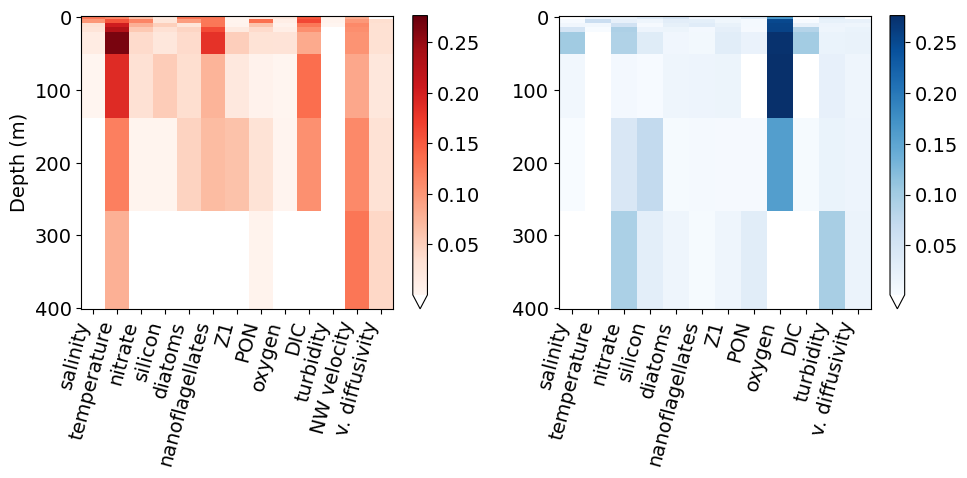

In [18]:
plot_how_extreme(how_extreme_high, how_extreme_low, nz, deptht, step, nfields, fields, nnames)

In [19]:
def plot_extreme(extreme, vmax=1):
    fig, ax = plt.subplots(1, 1, figsize=(5, 9))
    if extreme == 'low':
        ax.pcolormesh(tmask[zmaxlow[1]*step, ::step, ::step], cmap='Greens', vmax=2)
        colours = ax.pcolormesh(extreme_low[zmaxlow[0], zmaxlow[1]], cmap='Purples', vmax=vmax)
    else:
        ax.pcolormesh(tmask[zmaxhigh[1]*step, ::step, ::step], cmap='binary_r')
        colours = ax.pcolormesh(extreme_high[zmaxhigh[0], zmaxhigh[1]], cmap='Oranges', vmax=vmax)
    cb = fig.colorbar(colours, ax=ax)
    viz_tools.set_aspect(ax);
    if extreme == 'low':
        cb.set_label('(Previous Low - Current)/(Third Quartile - First Quartile)')
        dl = zmaxlow[1]
        kf = zmaxlow[0]
    else:
        cb.set_label('(Current - Previous High)/(Third Quartile - First Quartile)')
        dl = zmaxhigh[1]
        kf = zmaxhigh[0]
    ax.set_title(f'Extreme {extreme}, in {nnames[kf]} at {deptht[dl*step].values:.1f} m');

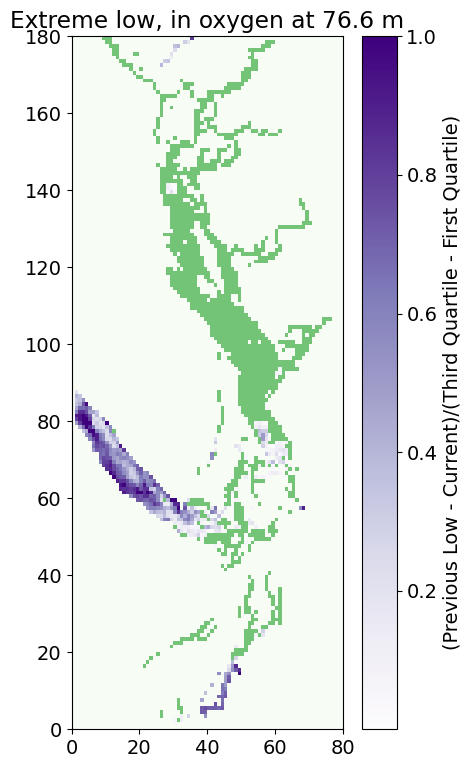

In [20]:
if how_extreme_high[zmaxhigh[0], zmaxhigh[1]] > how_extreme_low[zmaxlow[0], zmaxlow[1]]:
    extreme = 'high'
else:
    extreme = 'low'
plot_extreme(extreme, 1)

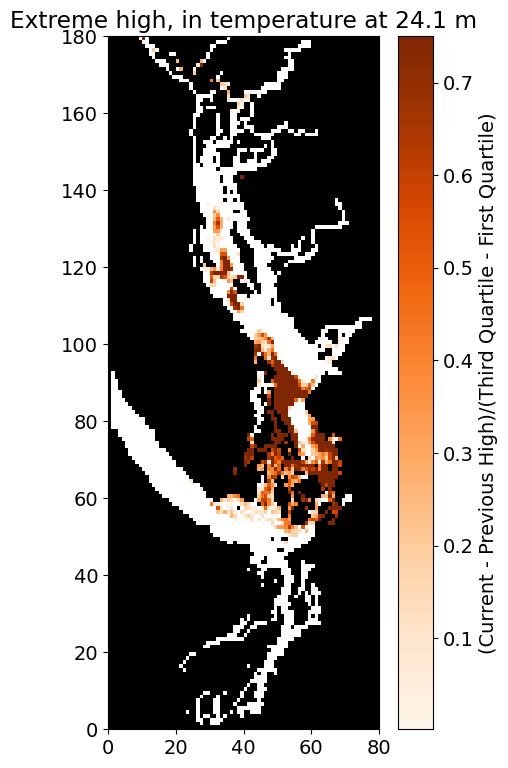

In [21]:
plot_extreme('high', 0.75)

In [22]:
def nine_plot(kf, dl, max_values, min_values, step, fields, nnames):
    fig, axs = plt.subplots(3, 3, figsize=(15, 25))
    field = fields[kf]
    fig.suptitle(f'Depth is {deptht[dl*step].values:.1f} m and field is {nnames[kf]}',
                y=0.92)
    
    if field == 'vosaline':
        cmap = cm.haline
    elif field == 'votemper':
        cmap = cm.thermal
    elif field == 'vomecrty':
        cmap = cm.curl
    elif field == 'nitrate':
        cmap = cm.rain
    elif field == 'dissolved_oxygen':
        cmap = cm.oxy
    elif field in ['diatoms', 'flagellates']:
        cmap = cm.algae   
    elif field in ['particulate_organic_nitrogen', 'dissolved_inorganic_carbon']:
        cmap = cm.matter
    elif field == 'vert_eddy_diff':
        cmap = cm.amp
    
    alpha = 0.25
    needed = max_values[kf, dl]
    vmax = np.nanmax(needed[needed !=0])
    needed = min_values[kf, dl]
    vmin = np.nanmin(needed[needed !=0])
    if field == 'vomecrty':
        vmax = max(vmax, -vmin)
        vmin = -vmax
    if field == 'diatoms':
        vmin = np.log(0.1)
    
    for ax in axs.flatten():
        ax.pcolormesh(tmask[dl*step, ::step, ::step], cmap='binary_r')
    
    # First Row
    colours = axs[0, 0].pcolormesh(mymask(max_values[kf, dl], dl, 1, tmask, step), vmin=vmin, vmax=vmax, cmap=cmap)
    fig.colorbar(colours, ax=axs[0, 0]);
    axs[0, 0].set_title('Maximum Values')
    
    colours = axs[0, 1].pcolormesh(mymask(min_values[kf, dl], dl, 1, tmask, step), vmin=vmin, vmax=vmax, cmap=cmap)
    fig.colorbar(colours, ax=axs[0, 1]);
    axs[0, 1].set_title('Minimum Values')
    
    colours = axs[0, 2].pcolormesh(mymask(now[kf, dl], dl, 1, tmask, step), vmin=vmin, vmax=vmax, cmap=cmap)
    fig.colorbar(colours, ax=axs[0, 2])
    axs[0, 2].set_title(f'{today}')
    
    # Second Row
    colours = axs[1, 0].pcolormesh(np.ma.array(now[kf, dl], mask=1-upper_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
 #   axs[1, 0].pcolormesh(mymask(now[kf, dl], dl, 1), vmax=vmax, cmap=cmap, alpha=alpha)
    fig.colorbar(colours, ax=axs[1, 0])
    axs[1, 0].set_title('Above Median')

   # axs[1, 1].pcolormesh(now[kf, dl], vmax=vmax, alpha=alpha, cmap=cmap)
    colours = axs[1, 1].pcolormesh(np.ma.array(now[kf, dl], mask=1-high_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
    fig.colorbar(colours, ax=axs[1, 1])
    axs[1, 1].set_title('Upper Quartile')
    
 #   axs[1, 2].pcolormesh(now[kf, dl], vmax=vmax, alpha=alpha, cmap=cmap)
    colours = axs[1, 2].pcolormesh(np.ma.array(now[kf,dl], mask=1-max_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
    axs[1, 2].set_title('New Maximum');
    fig.colorbar(colours, ax=axs[1, 2]);
    
    # Third Row
 #   axs[2, 0].pcolormesh(mymask(now[kf,dl], dl, 1), vmax=vmax, cmap=cmap, alpha=alpha)
    colours = axs[2, 0].pcolormesh(np.ma.array(now[kf, dl], mask=1-lower_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
    fig.colorbar(colours, ax=axs[2, 0])
    axs[2, 0].set_title('Below Median')
    
 #   axs[2, 1].pcolormesh(now[kf, dl], vmax=vmax, alpha=alpha, cmap=cmap)
    colours = axs[2, 1].pcolormesh(np.ma.array(now[kf, dl], mask=1-low_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
    fig.colorbar(colours, ax=axs[2, 1])
    axs[2, 1].set_title('Lower Quartile')
    
 #   axs[2, 2].pcolormesh(now[kf, dl], vmax=vmax, alpha=alpha, cmap=cmap)
    colours = axs[2, 2].pcolormesh(np.ma.array(now[kf,dl],mask=1-min_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
    axs[2, 2].set_title('New Minimum');
    fig.colorbar(colours, ax=axs[2, 2]);
    
    for ax in axs.flatten():
            viz_tools.set_aspect(ax)

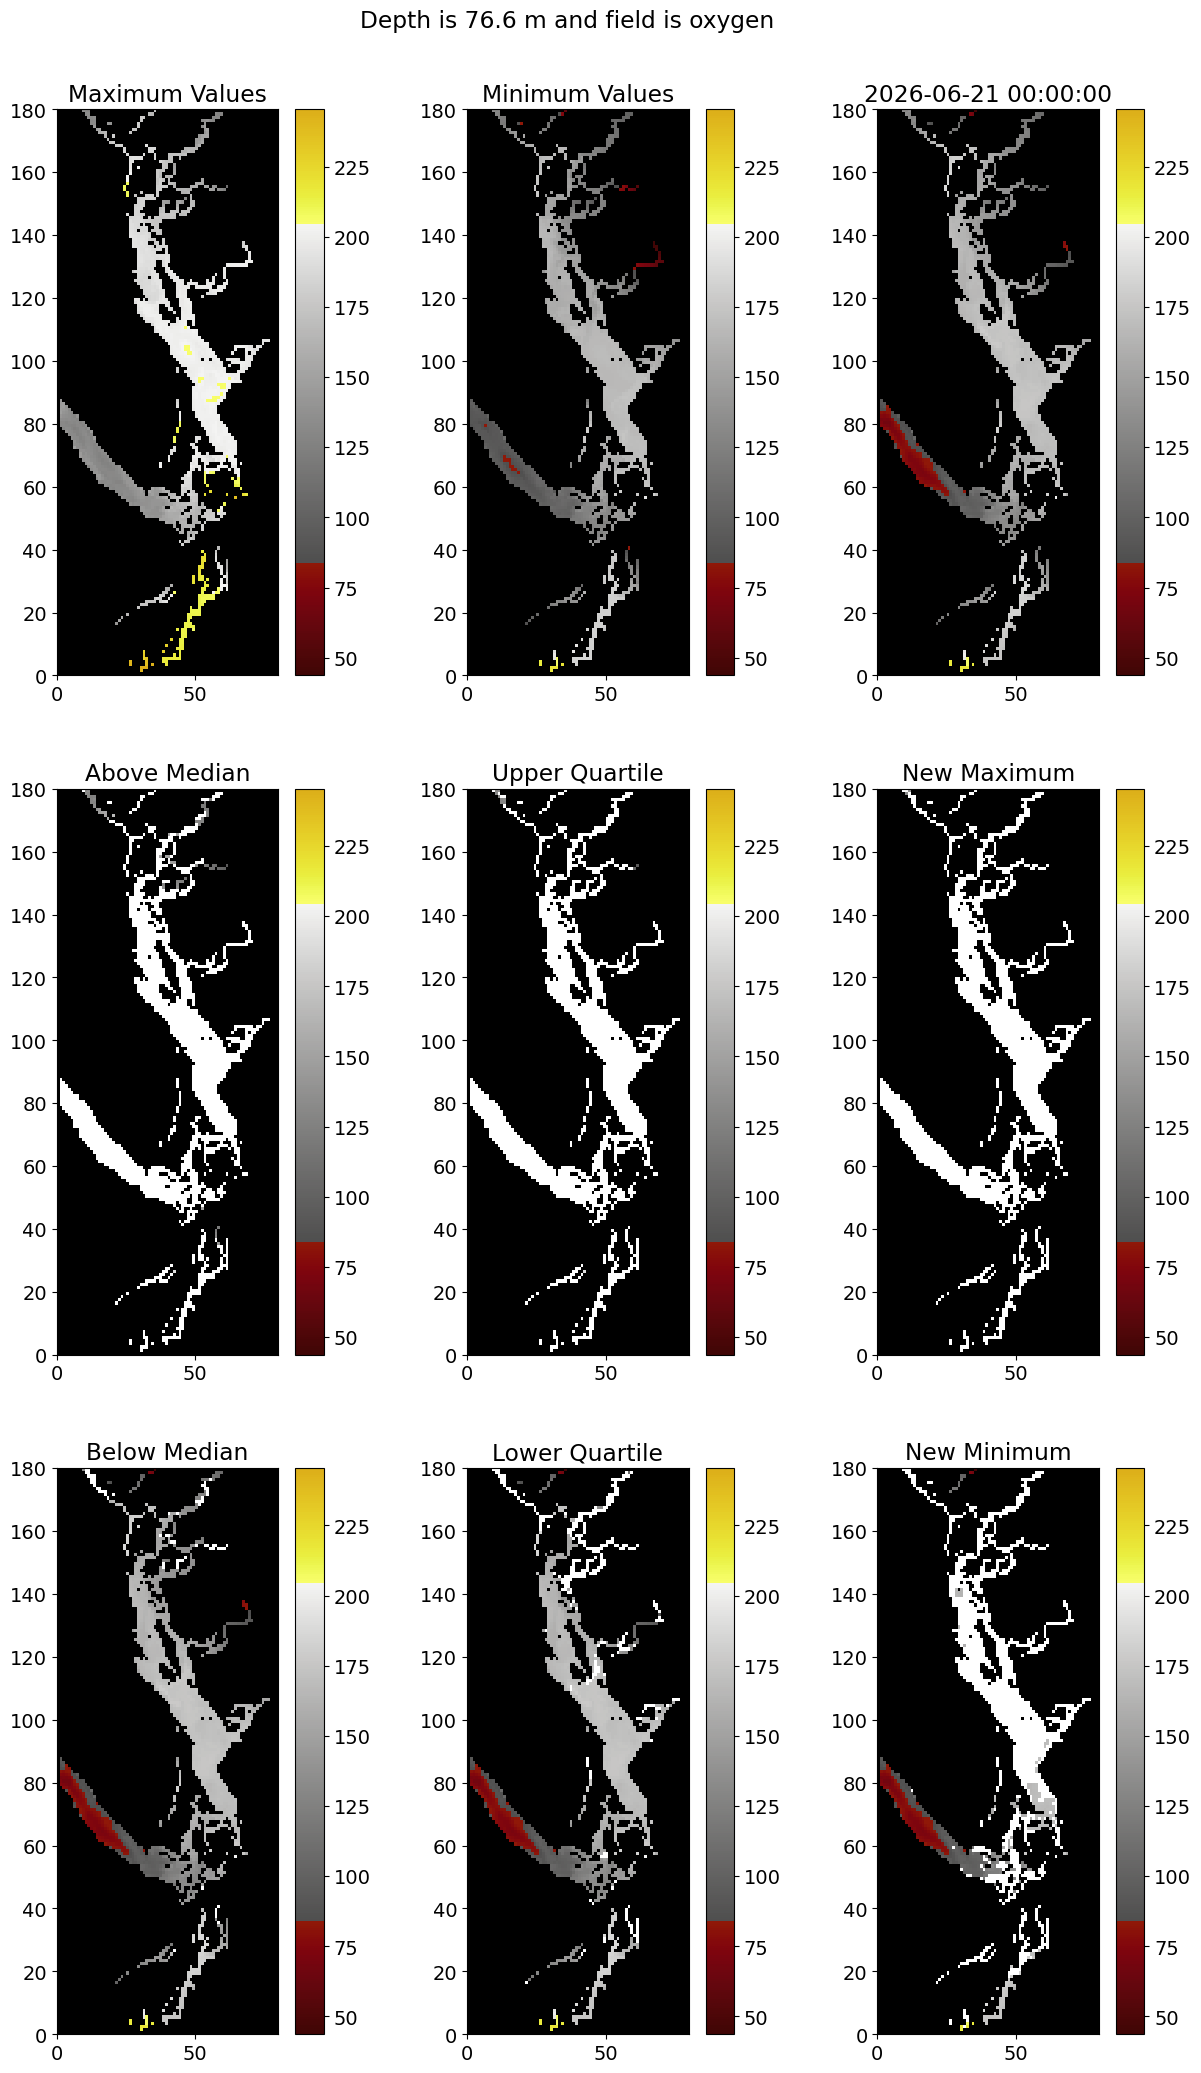

In [23]:
if extreme == 'low':
    dl = zmaxlow[1]
    kf = zmaxlow[0]
else:
    dl = zmaxhigh[1]
    kf = zmaxhigh[0]

field = fields[kf]
if field == 'vosaline':
    cmap = cm.haline
elif field == 'votemper':
    cmap = cm.thermal

needed = max_values[kf, dl]
vmax = np.nanmax(needed[needed !=0])
needed = min_values[kf, dl]
vmin = np.nanmin(needed[needed !=0])
nine_plot(kf, dl, max_values, min_values, step, fields, nnames)

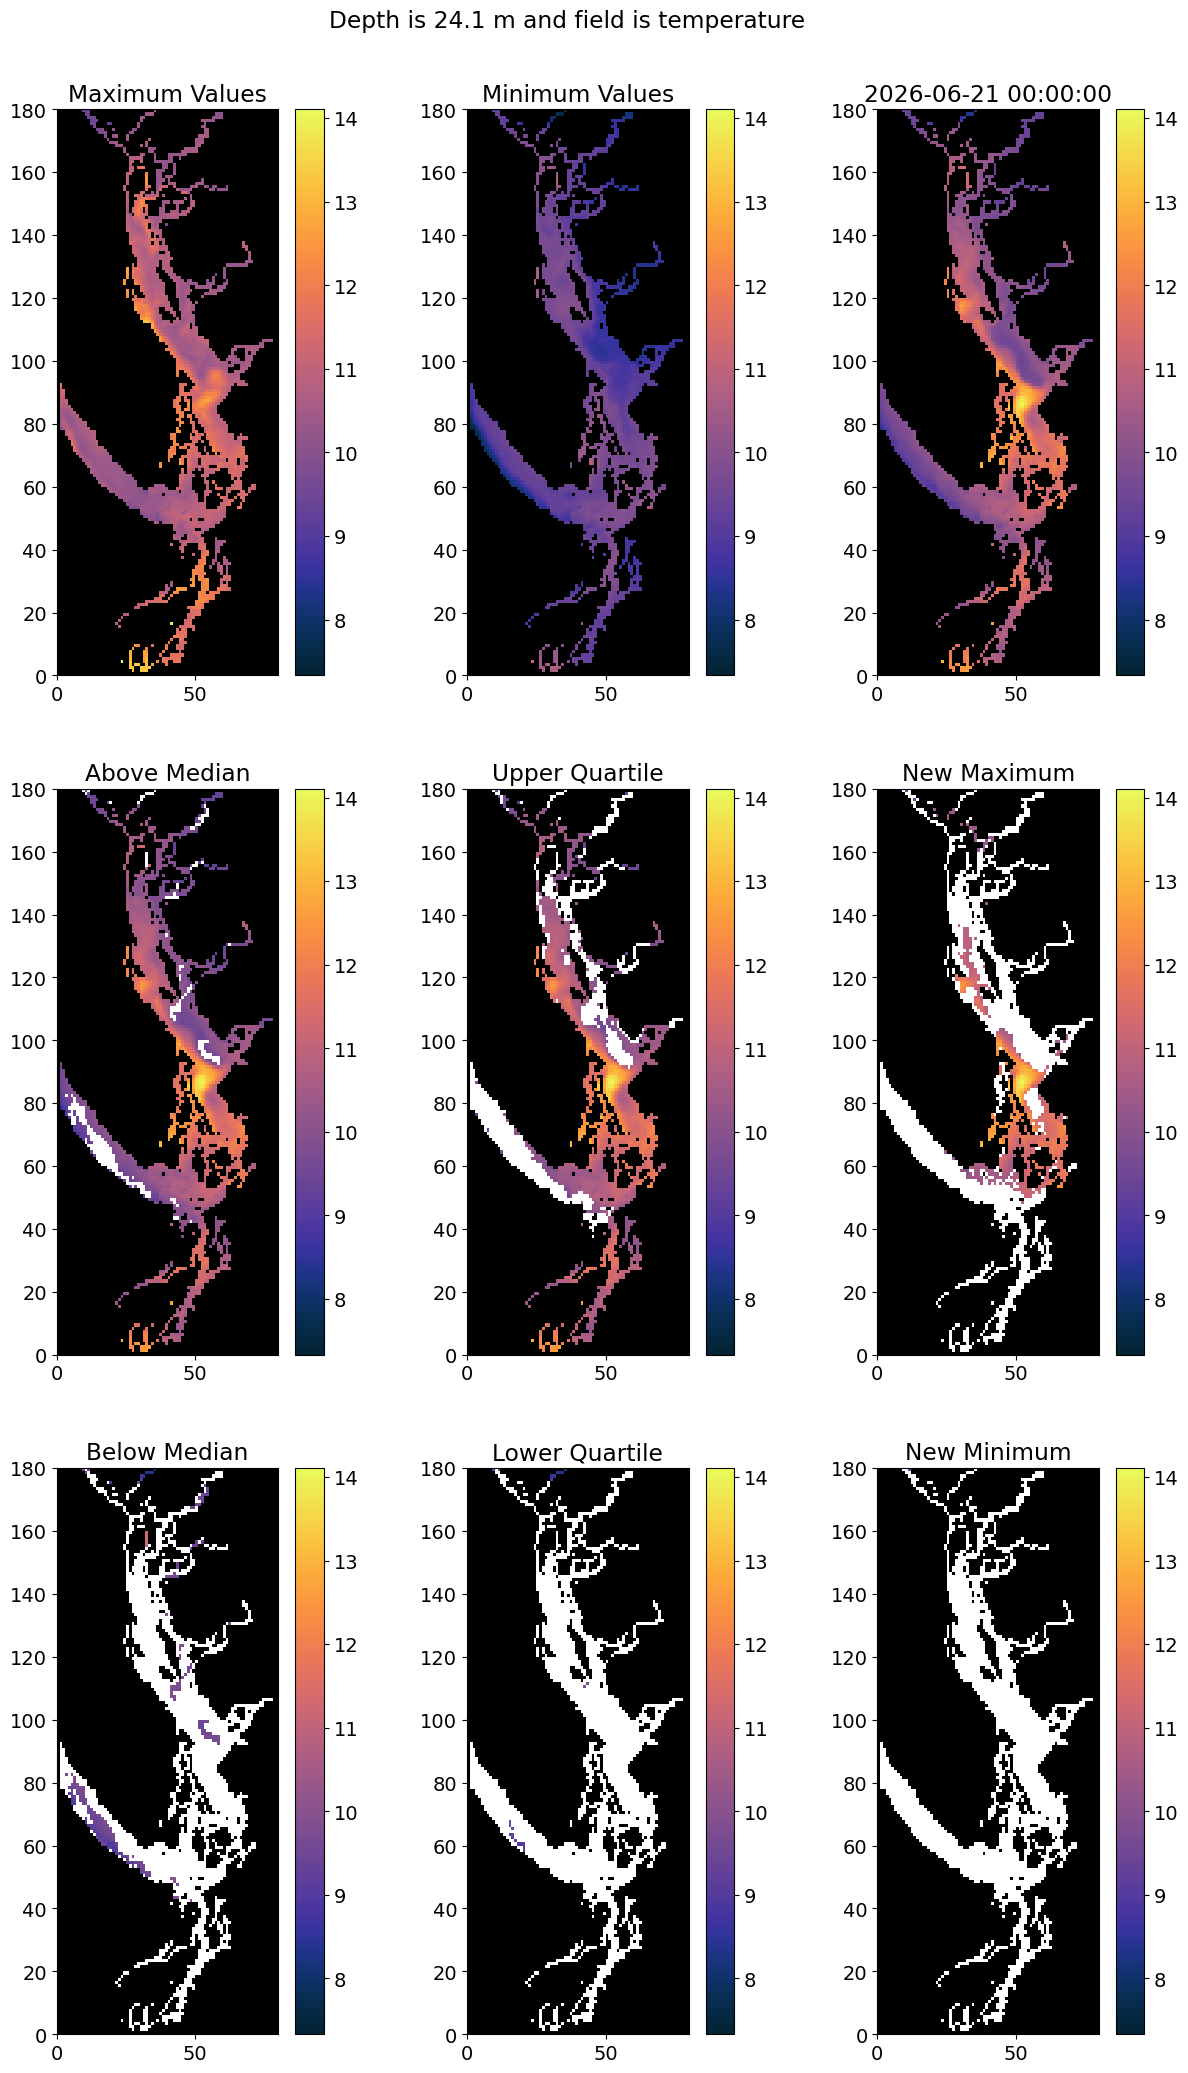

In [24]:
if extreme == 'high':
    nine_plot(zmaxlow[0], zmaxlow[1], max_values, min_values, step, fields, nnames)
else:
    nine_plot(zmaxhigh[0], zmaxhigh[1], max_values, min_values, step, fields, nnames)

In [25]:
def big_plot(kf, dl, extreme, vmax, vmin, cmap, extreme_only=False):
    fig, ax = plt.subplots(1, 1, figsize=(10, 18))
    ax.set_title(f'Depth is {deptht[dl*step].values:.1f} m and field is {nnames[kf]}')
    
    ax.pcolormesh(tmask[dl*step, slice_y, slice_x], cmap='binary_r')
    print (vmax, vmin)
    if not extreme_only:
        ax.pcolormesh(now_values[kf, dl], vmin=vmin, vmax=vmax, alpha=0.2, cmap=cmap)
    if extreme == 'low':
        colours = ax.pcolormesh(np.ma.array(now[kf, dl], mask=1-min_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
    else:
        colours = ax.pcolormesh(np.ma.array(now[kf, dl], mask=1-max_mask[kf, dl]), vmin=vmin, vmax=vmax, cmap=cmap)
    fig.colorbar(colours, ax=ax);
    if extreme == 'low':
        ax.contour(extreme_low[kf, dl], [0.2, 1, 2, 5], colors=['b', 'g', 'orange', 'r'])
        ax.text(0, 750/step, 'Blue Contour:\n 0.2 x third -\n first quartile\n below Minimum', color='b')
        ax.text(0, 650/step, 'Green Contour:\n 1 x third -\n first quartile\n below Minimum', color='g')
        ax.text(0, 500/step, 'Orange Contour:\n 2 x third - first quartile\n below Minimum', color='orange')
        ax.text(0, 200/step, 'Red Contour:\n 5 x third - first quartile\n below Minimum', color='r')
    else:
        ax.contour(extreme_high[kf, dl], [0.2, 1, 2, 5], colors=['b', 'g', 'orange', 'r'])
        ax.text(0, 750/step, 'Blue Contour:\n 0.2 x third -\n first quartile\n above Maximum', color='b')
        ax.text(0, 650/step, 'Green Contour:\n 1 x third -\n first quartile\n above Maximum', color='g')
        ax.text(0, 500/step, 'Orange Contour:\n 2 x third - first quartile\n above Maximum', color='orange')
        ax.text(0, 200/step, 'Red Contour:\n 5 x third - first quartile\n above Maximum', color='r')
    
    viz_tools.set_aspect(ax);

245.42201232910156 43.65823745727539


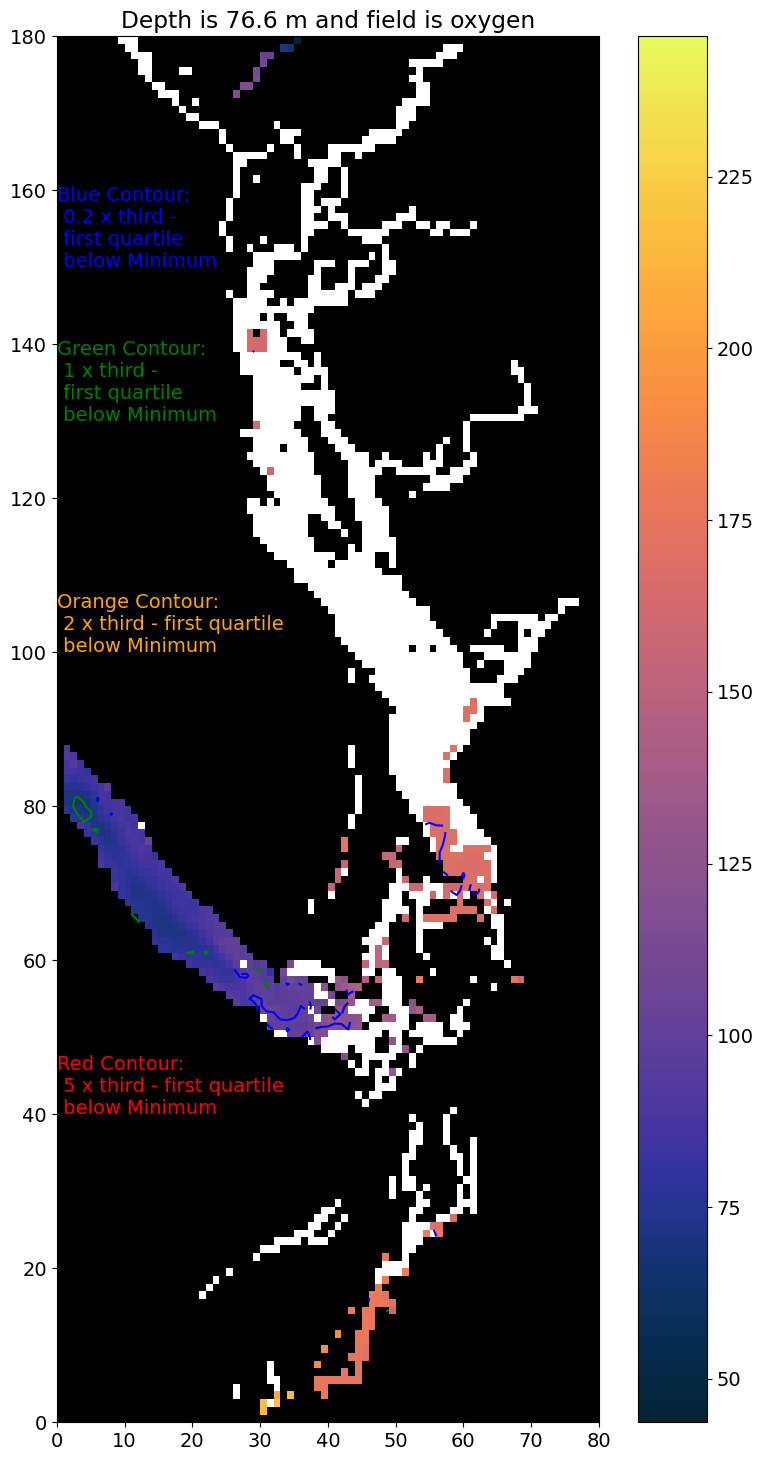

In [26]:
#big_plot(kf, dl, extreme, vmax=vmax, vmin=np.log(0.1), cmap=cm.matter, extreme_only=True);
big_plot(kf, dl, extreme, vmax=vmax, vmin=vmin, cmap=cm.thermal, extreme_only=True);

14 10


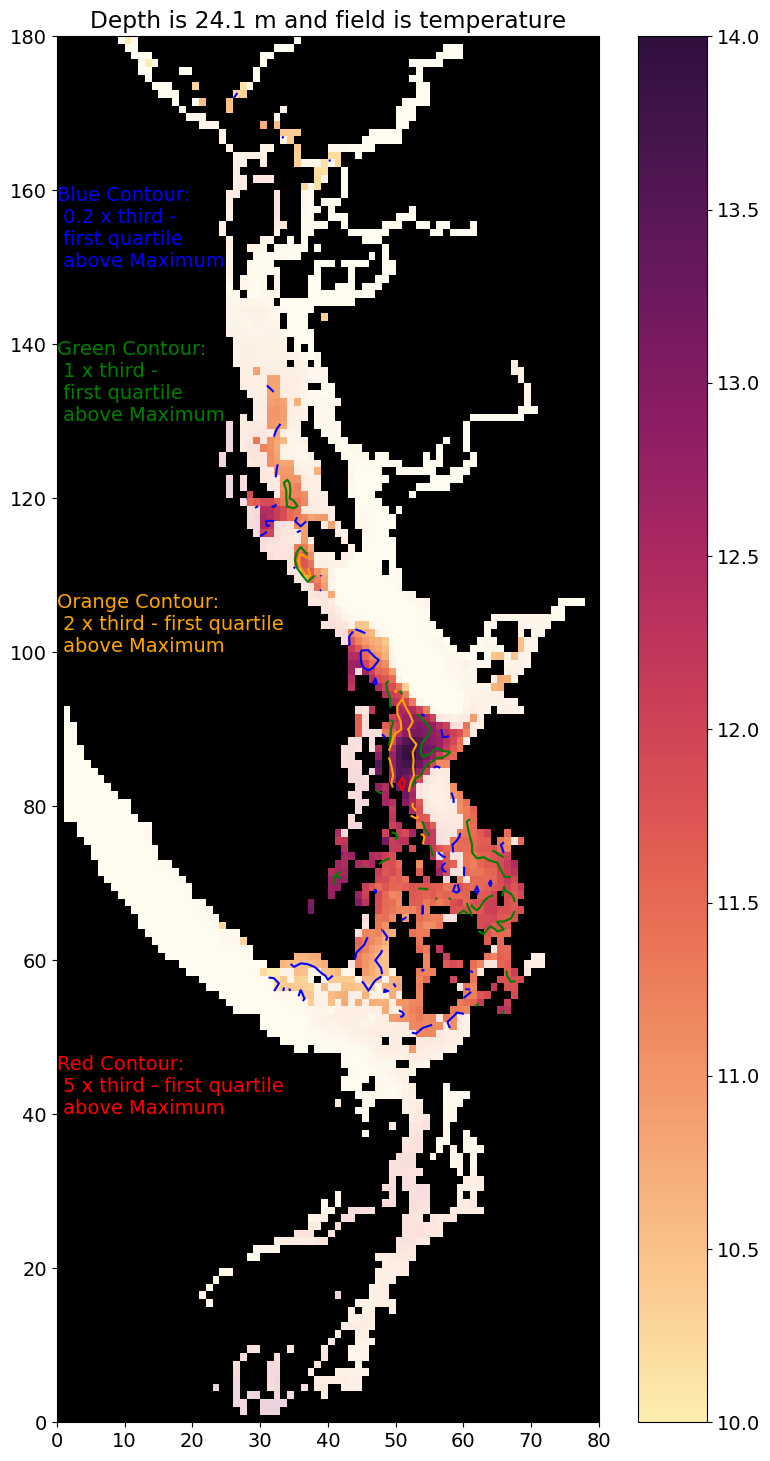

In [28]:
if extreme == 'high':
    big_plot(zmaxlow[0], zmaxlow[1], 'low', vmin=-0.15, vmax=0.15, cmap=cm.curl, extreme_only=True);
else:
    big_plot(zmaxhigh[0], zmaxhigh[1], 'high', vmin=10, vmax=14, cmap=cm.matter)

In [29]:
# a point 120, 250
def plot_cross(kf, dl, ii=int(500/step), js=int(160/step), je = int(290/step)):

    fig, ax = plt.subplots(1, 1)
    ax.plot(now_values[kf, dl, ii, js:je])
    ax.plot(median_values[kf, dl, ii, js:je], linewidth=3)
    ax.plot(low_values[kf, dl, ii, js:je], c='tab:orange')
    ax.plot(min_values[kf, dl, ii, js:je], c='tab:orange')
    ax.plot(high_values[kf, dl, ii, js:je], c='tab:orange')
    ax.plot(max_values[kf, dl, ii, js:je], c='tab:orange');
    ax.set_title(f'Across Strait, ii = {ii*step}, depth = {deptht[dl*step].values:.1f} m for {nnames[kf]}');
    return ax

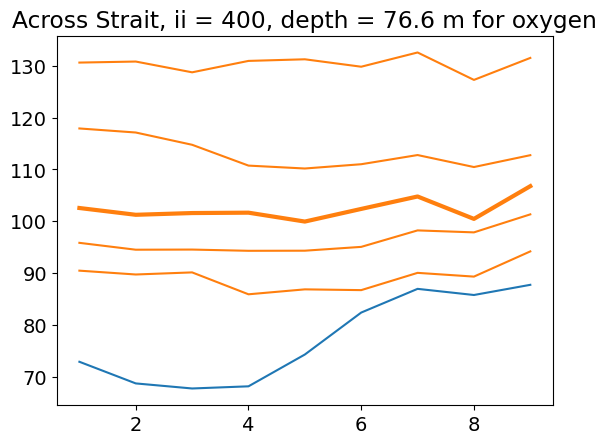

In [30]:
plot_cross(kf, dl, ii=80, js=0, je=40);

In [31]:
spi, spj = 80, 3
print (now_values[kf, dl, spi, spj], min_values[kf, dl, spi, spj])

67.76884460449219 90.14971160888672


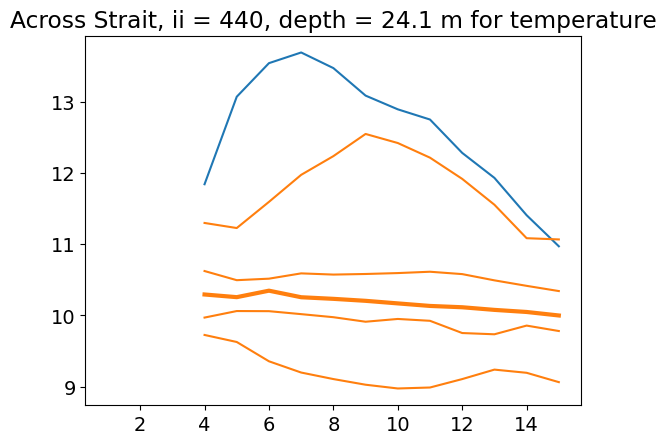

In [33]:
if extreme == 'high':
    ax = plot_cross(zmaxlow[0], zmaxlow[1], ii=98, js=0, je=290);
else:
    ax = plot_cross(zmaxhigh[0], zmaxhigh[1], ii=88, js=45, je=100)

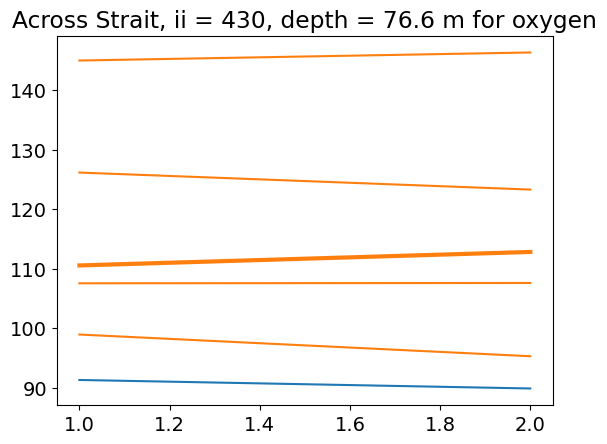

In [34]:
ax = plot_cross(8, dl, ii=86, js=0, je=40);

# Time Series #

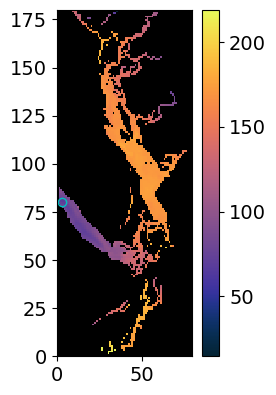

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(2.5, 4.5))
mymap = copy.copy(cm.thermal)
mymap.set_bad('k')
colours = ax.pcolormesh(now_values[kf, dl, :, :], cmap=mymap)
ax.plot(spj, spi, 'o', fillstyle='none', markeredgecolor='c')
viz_tools.set_aspect(ax);
fig.colorbar(colours);

In [36]:
def get_ts_now(kf, dl, spi, spj, ndays):
    ts = np.zeros((ndays+1))
    mydays = []
    for iday in np.arange(ndays, -1, -1):
        day = today + dt.timedelta(days=-int(iday*tstep))
        dirstring = day.strftime("%d%b%y").lower()
        timestring = f'{day.year}{day.month:02d}{day.day:02d}'
        if file4fields[kf] == '':
            datafile = xr.open_dataset(salishdir / dirstring /f'SalishSea_1d_{timestring}_{timestring}_grid_T.nc')
        elif file4fields[kf] == 'b':
            datafile = xr.open_dataset(salishdir / dirstring /f'SalishSea_1d_{timestring}_{timestring}_biol_T.nc')
        elif file4fields[kf] == 'c':
            datafile = xr.open_dataset(salishdir / dirstring /f'SalishSea_1d_{timestring}_{timestring}_chem_T.nc')
        else:
            print ('add another field')
            break
        ts[ndays-iday] = datafile[fields[kf]][0, dl*step, spi*step, spj*step]
        datafile.close()
        mydays.append(day)
    return mydays, ts

In [37]:
def get_ts_history(kf, dl, spi, spj, ndays):
    hts = np.zeros((yearrange[1] - yearrange[0] + 1, ndays+1))
    for iy, year in enumerate(range(yearrange[0], yearrange[1]+1)):
        print (year)
        for iday in np.arange(ndays, -1, -1):
            day = dt.datetime(year, today.month, today.day) + dt.timedelta(days=-int(iday*tstep))
            dirstring = day.strftime("%d%b%y").lower()
            timestring = f'{day.year}{day.month:02d}{day.day:02d}'
            if file4fields[kf] == '':
                datafile = xr.open_dataset(salishdir / dirstring /f'SalishSea_1d_{timestring}_{timestring}_grid_T.nc')
            elif file4fields[kf] == 'b':
                datafile = xr.open_dataset(salishdir / dirstring /f'SalishSea_1d_{timestring}_{timestring}_biol_T.nc')
            elif file4fields[kf] == 'c':
                datafile = xr.open_dataset(salishdir / dirstring /f'SalishSea_1d_{timestring}_{timestring}_chem_T.nc')
            else:
                print ('add another field')
                break
            hts[iy, ndays-iday] = datafile[fields[kf]][0, dl*step, spi*step, spj*step]
            datafile.close()
    return hts

In [41]:
def plot_ts(mydays, ts, hts, kf, dl, spi, spj):
    fig, axs = plt.subplots(2, 1, figsize=(10, 8))
    
    norm = mcolors.Normalize(vmin=yearrange[0], vmax=yearrange[1]) # Scale based on your data range
    
    axs[0].plot(mydays, ts, linewidth=5);
    mqmqm = 'tab:green'
    axs[0].plot(mydays, np.median(hts, axis=0), color=mqmqm, linewidth=5)
    axs[0].fill_between(mydays, hts.min(axis=0), hts.max(axis=0), color='tab:green', alpha=0.1)
    axs[0].fill_between(mydays, np.quantile(hts, 0.25, axis=0), np.quantile(hts, 0.75, axis=0), color='tab:green', alpha=0.2)
    
    for iy, year in enumerate(range(yearrange[0], yearrange[1]+1)):
        if year in [2015, 2016]:
            linewidth = 3
        else:
            linewidth = 2
        color = cm.thermal(norm(year)) 
        axs[0].plot(mydays, hts[iy, :], color=color, alpha=0.7, linewidth=linewidth)
    axs[0].tick_params(axis='x', labelrotation=45)
    axs[0].grid()
    axs[0].set_title(f'Time Series, ii = {spi*step}, jj = {spj*step}, depth = {deptht[dl*step].values:.1f} m for {nnames[kf]}');
    
    sm = plt.cm.ScalarMappable(cmap=cm.thermal, norm=norm)
    fig.colorbar(sm, ax=axs[0], label="Year");

    axs[1].pcolormesh(mydays, range(yearrange[0], yearrange[1]+1+1), np.vstack([hts, ts]))
    colours = axs[1].tick_params(axis='x', labelrotation=45)
    fig.colorbar(colours, ax=axs[1])

    fig.tight_layout()

    return fig, axs

In [42]:
print (today)
tstep = 5
print (today + dt.timedelta(days=-10*tstep))
ndays = 15

2026-06-21 00:00:00
2026-05-02 00:00:00


In [39]:
mydays, ts = get_ts_now(kf, dl, spi, spj, ndays)
hts = get_ts_history(kf, dl, spi, spj, ndays)

2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025


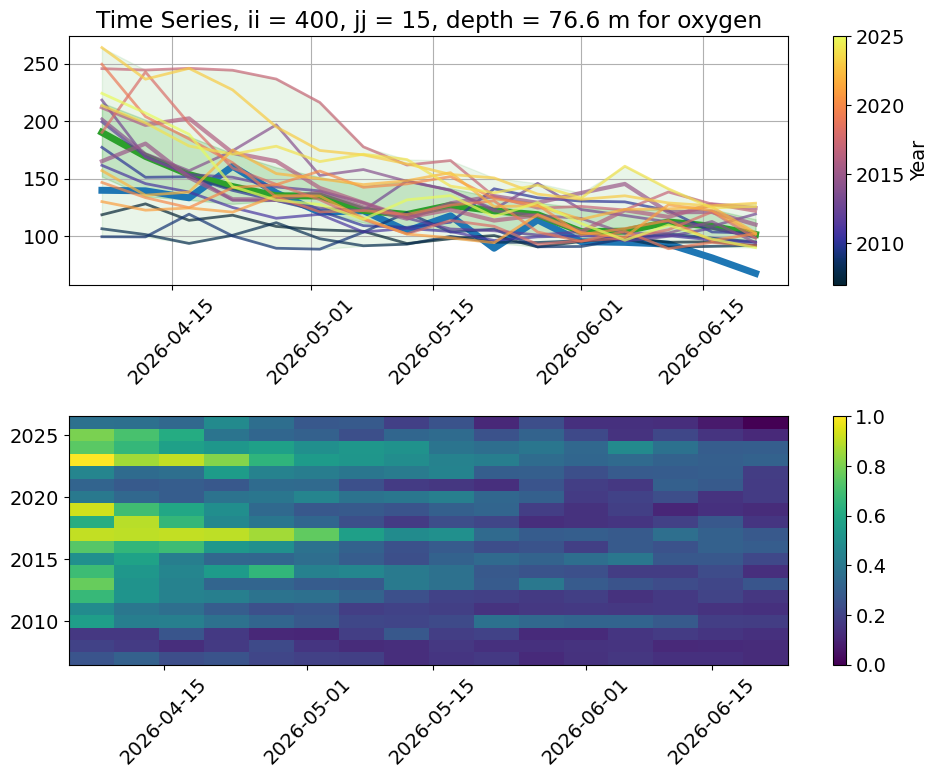

In [43]:
plot_ts(mydays, ts, hts, kf, dl, spi, spj);

In [44]:
mydays, ts = get_ts_now(1, dl, spi, spj, ndays)
hts = get_ts_history(1, dl, spi, spj, ndays)

2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025


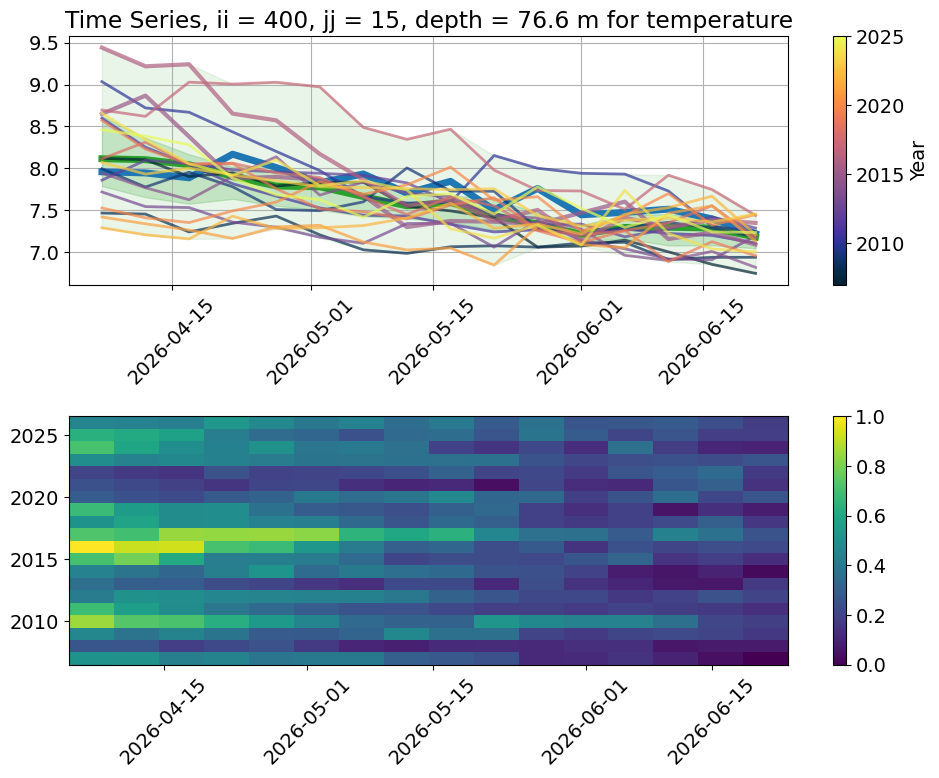

In [45]:
plot_ts(mydays, ts, hts, 1, dl, spi, spj);

In [46]:
mydays, ts = get_ts_now(0, dl, spi, spj, ndays)
hts = get_ts_history(0, dl, spi, spj, ndays)

2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025


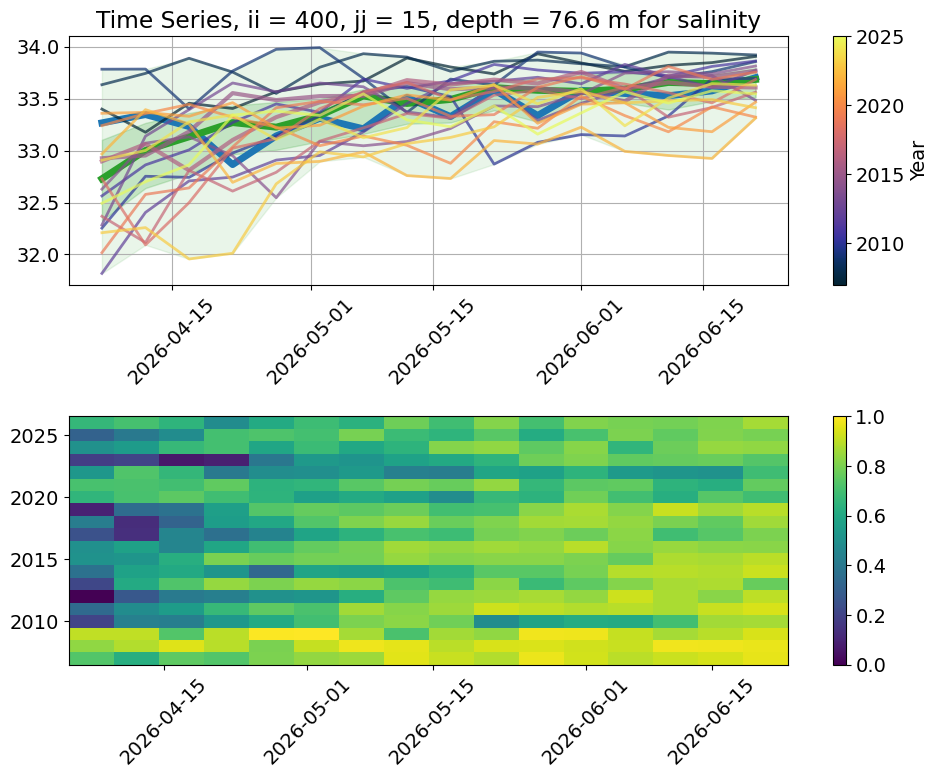

In [47]:
plot_ts(mydays, ts, hts, 0, dl, spi, spj);

In [ ]:
# DIC
myi, myj = 105, 54
mdl = 0
mydays, ts = get_ts_now(9, mdl, myi, myj, ndays)
hts = get_ts_history(9, mdl, myi, myj, ndays)

2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025


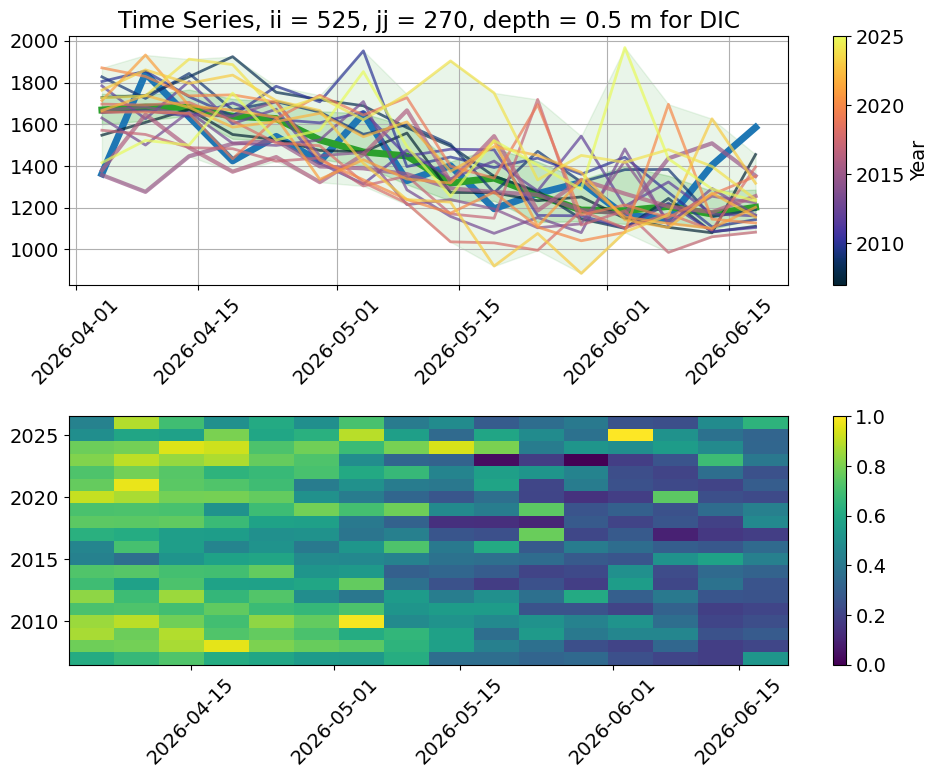

In [ ]:
plot_ts(mydays, ts, hts, 9, mdl, myi, myj);

In [49]:
# Temperature South SoG
myi, myj = 88, 52
mdl = zmaxhigh[1]
mydays, ts = get_ts_now(1, mdl, myi, myj, ndays)
hts = get_ts_history(1, mdl, myi, myj, ndays)

2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025


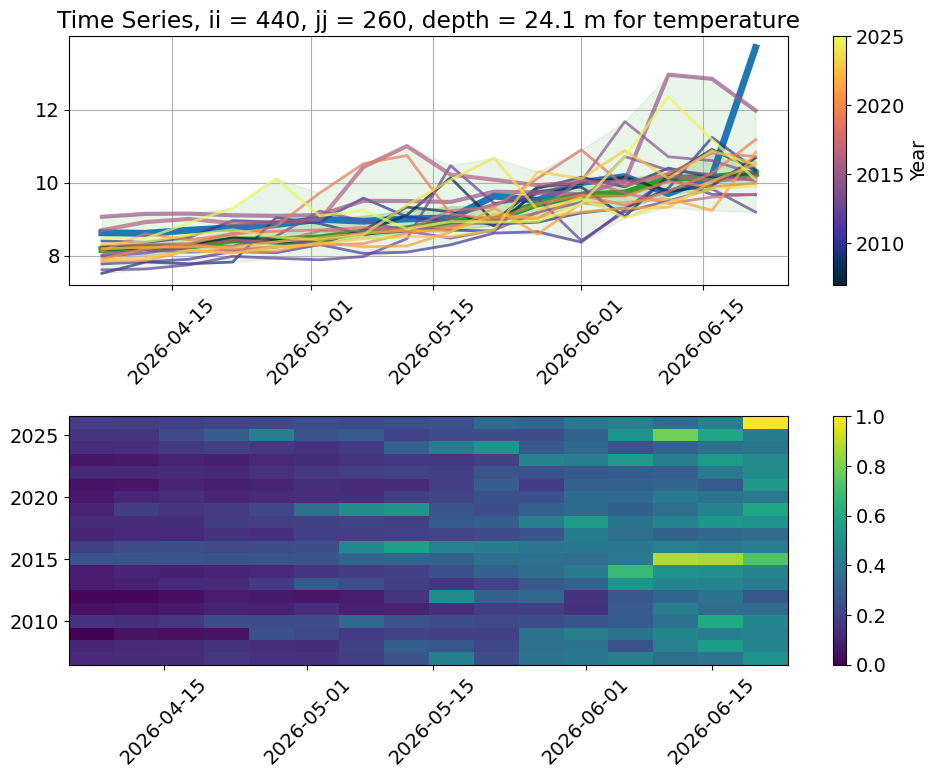

In [50]:
plot_ts(mydays, ts, hts, 1, mdl, myi, myj);

In [51]:
# Oxygen at Mouth
myi, myj = 86, 1
mydl = 5
mydays, ts = get_ts_now(8, mydl, myi, myj, ndays)
hts = get_ts_history(8, mydl, myi, myj, ndays)

2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025


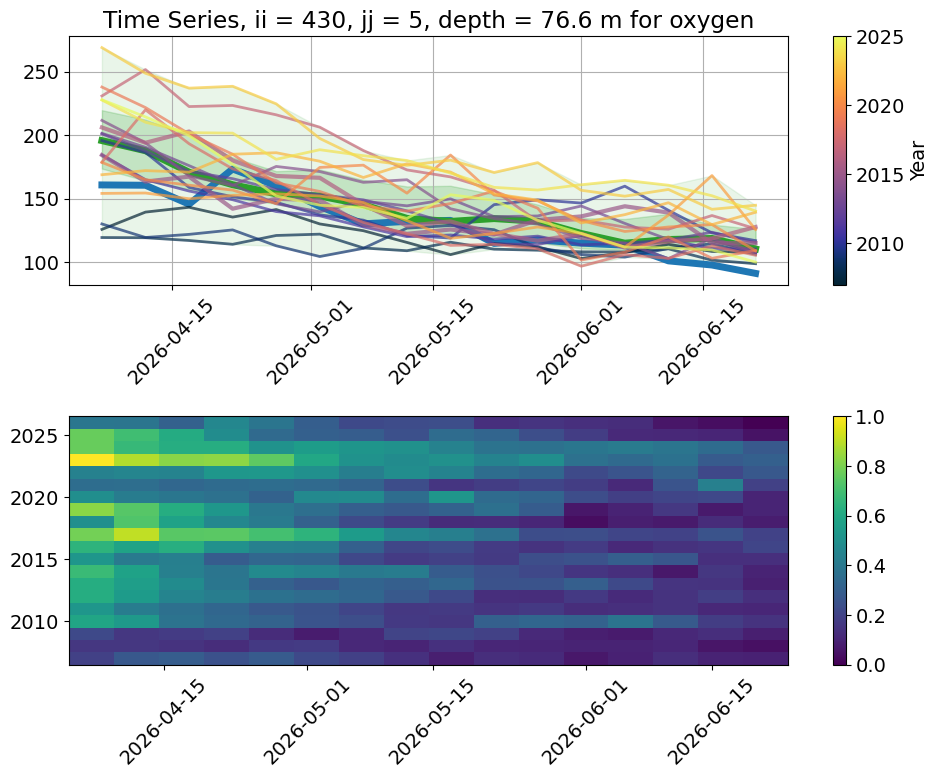

In [52]:
plot_ts(mydays, ts, hts, 8, mydl, myi, myj);

## Thalweg ##

In [53]:
importlib.reload(visualisations)

<module 'salishsea_tools.visualisations' from '/ocean/sallen/allen/research/Meopar/tools/SalishSeaTools/salishsea_tools/visualisations.py'>

In [54]:
bathymetry = xr.open_dataset('/home/sallen/MEOPAR/grid/bathymetry_202108.nc', mask_and_scale=False)
var = datafilen.vosaline[0]
gdept = mesh.gdept_0[0].values
lines = np.loadtxt('/home/sallen/MEOPAR/Tools/bathymetry/thalweg_working.txt', delimiter=" ", unpack=False)
lines = lines.astype(int)

thalweg_lon = mesh.nav_lon.values[lines[:,0], lines[:,1]]
thalweg_lat = mesh.nav_lat.values[lines[:,0], lines[:,1]]

dep_thal, xx_thal, var_thal = visualisations.load_thalweg(gdept, var.values, bathymetry.nav_lon.values,
                                                          bathymetry.nav_lat.values, lines)

distance_along_thalweg = xx_thal[0, 0]
print (dep_thal.shape, xx_thal.shape)



(40, 1533) (40, 1533)


In [55]:
clevels = 2*np.array([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1])
clevels

array([-2. , -1.5, -1. , -0.5,  0. ,  0.5,  1. ,  1.5,  2. ])

In [56]:
meshgrid = nc.Dataset('/home/sallen/MEOPAR/grid/mesh_mask202108.nc')
bathymetry = nc.Dataset('/home/sallen/MEOPAR/grid/bathymetry_202108.nc')
    
def contour_plot(kf, now, median_values, scale=1):
    fig, ax = plt.subplots(1, 1, figsize=(15,5))
    visualisations.contour_thalweg(ax, now - median_values, bathymetry, meshgrid, 
                                   clevels=scale*np.array([-1, -0.75, -0.5, -0.25, 0, 0.25, 0.5, 0.75, 1]), 
          #                         clevels=np.arange(-0.1, 0.11, 0.01),
                                   cmap='bwr', xcoord_distance=True);
    ax.set_title(f'{nnames[kf]}, now - median values')
#    ax.set_xlim(700, None)

In [57]:
print (kf, field)

8 dissolved_oxygen


In [58]:
def get_tnow(kf, field, tnow):
    dirstring = today.strftime("%d%b%y").lower()
    timestring = f'{today.year}{today.month:02d}{today.day:02d}'
    
    if file4fields[kf] == '':
        datafilen = xr.open_dataset(salishdir / dirstring /f'SalishSea_1d_{timestring}_{timestring}_grid_T.nc')
        tnow = datafilen[field][0]
    elif file4fields[kf] == 'b':
        datafilen = xr.open_dataset(salishdir / dirstring / f'SalishSea_1d_{timestring}_{timestring}_biol_T.nc')
        tnow = datafilen[field][0]
    elif file4fields[kf] == 'c':
        datafilen = xr.open_dataset(salishdir / dirstring / f'SalishSea_1d_{timestring}_{timestring}_chem_T.nc')
        tnow = datafilen[field][0]
    elif file4fields[kf] == 'v':
        datafilen = xr.open_dataset(salishdir / dirstring / f'SalishSea_1h_{timestring}_{timestring}_grid_V.nc')
        tnow = datafilen[field][:].mean(axis=0)
    elif file4fields[kf] == 'w':
        datafilen = xr.open_dataset(salishdir / dirstring / f'SalishSea_1h_{timestring}_{timestring}_grid_W.nc')
        tnow = datafilen[field][st]
    datafilen.close()
    return tnow

In [59]:
def get_thistory(kf, field, thistory):
    for iy, year in enumerate(range(yearrange[0], yearrange[1]+1)):
        print (year)
        dirstring = dt.datetime(year, today.month, today.day).strftime("%d%b%y").lower()
        timestring = f'{year}{today.month:02d}{today.day:02d}'
        if file4fields[kf] == '':
            datafile = xr.open_dataset(salishdir / dirstring /f'SalishSea_1d_{timestring}_{timestring}_grid_T.nc')
            thistory[iy] = datafile[field][0]
        elif file4fields[kf] == 'b':
            datafile = xr.open_dataset(salishdir / dirstring / f'SalishSea_1d_{timestring}_{timestring}_biol_T.nc')
            thistory[iy] = datafile[field][0]
        elif file4fields[kf] == 'c':
            datafile = xr.open_dataset(salishdir / dirstring / f'SalishSea_1d_{timestring}_{timestring}_chem_T.nc')
            thistory[iy] = datafile[field][0]
        elif file4fields[kf] == 'v':
            datafile = xr.open_dataset(salishdir / dirstring / f'SalishSea_1h_{timestring}_{timestring}_grid_V.nc')
            thistory[iy] = datafile[field][:].mean(axis=0)
        elif file4fields[kf] == 'w':
            datafile = xr.open_dataset(salishdir / dirstring / f'SalishSea_1h_{timestring}_{timestring}_grid_W.nc')
            thistory[iy] = datafile[field][st]
        datafile.close()
    return thistory

In [60]:
nz, ny, nx = 40, 898, 398
thistory = np.zeros((yearrange[1] - yearrange[0] + 1, nz, ny, nx))
tnow = np.zeros_like(thistory[0])
tnow = get_tnow(kf, field, tnow)
thistory = get_thistory(kf, field, thistory)

2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025


In [61]:
#max_values = mymask(history.max(axis=1), np.arange(nz), nfields)
#min_values = mymask(history.min(axis=1), np.arange(nz), nfields)
tmedian_values = mymask(np.median(thistory, axis=0), np.arange(nz), 1, tmask, step=1)
#high_values = mymask(np.quantile(history, 0.75, axis=1), np.arange(nz), nfields)
#low_values = mymask(np.quantile(history, 0.25, axis=1), np.arange(nz), nfields)

/ocean/sallen/allen/research/Meopar/tools/SalishSeaTools/salishsea_tools/visualisations.py:256: UserWarning: Warning: converting a masked element to nan.
  newvar[level, i] = variable[level - 1, i]


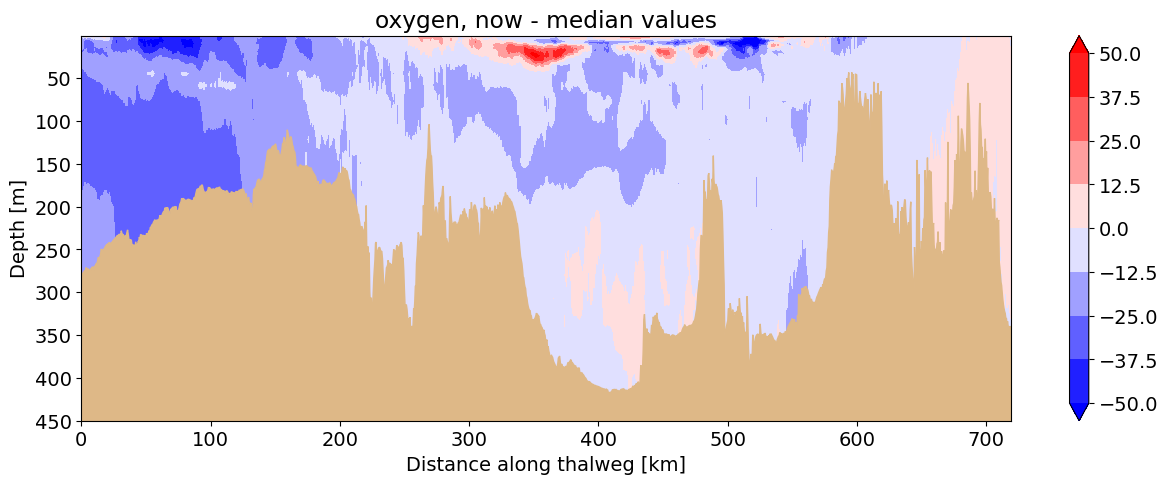

In [62]:
contour_plot(kf, tnow.values, tmedian_values, scale=50)

In [63]:
nz, ny, nx = 40, 898, 398
thistory_min = np.zeros((yearrange[1] - yearrange[0] + 1, nz, ny, nx))
tnow_min = np.zeros_like(thistory_min[0])
if extreme == 'high':
    kf_low = zmaxlow[0]
else:
    kf_low = zmaxhigh[0]
tnow_min = get_tnow(kf_low, fields[kf_low], tnow_min)
thistory_min = get_thistory(kf_low, fields[kf_low], thistory_min)

2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025


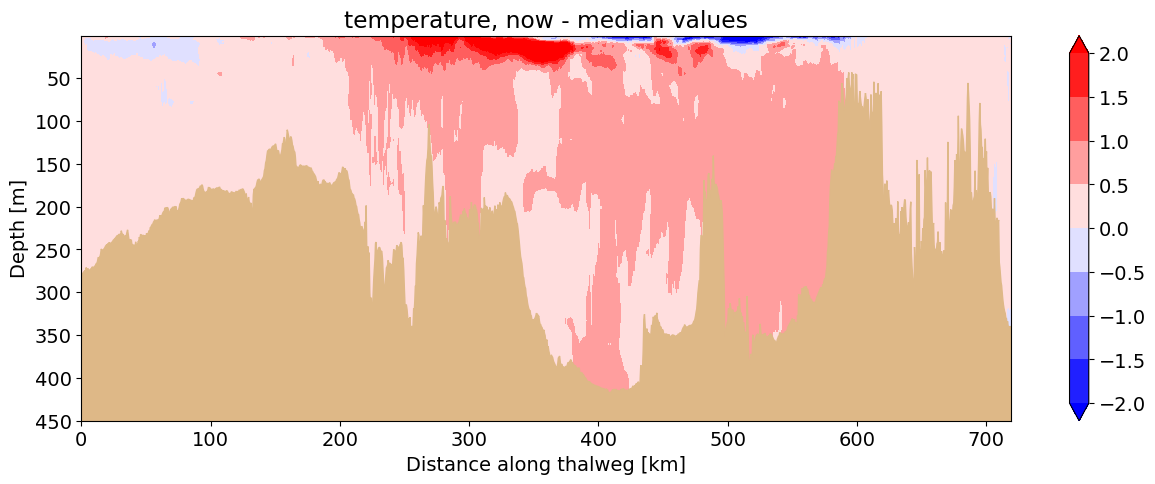

In [65]:
tmedian_min_values = mymask(np.median(thistory_min, axis=0), np.arange(nz), 1, tmask, step=1)
contour_plot(kf_low, tnow_min.values, tmedian_min_values, scale=2)

In [66]:
nz, ny, nx = 40, 898, 398
thistory_ano = np.zeros((yearrange[1] - yearrange[0] + 1, nz, ny, nx))
tnow_ano = np.zeros_like(thistory_ano[0])
kf_ano = 2
tnow_ano = get_tnow(kf_ano, fields[kf_ano], tnow_ano)
thistory_ano = get_thistory(kf_ano, fields[kf_ano], thistory_ano)

2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025


/ocean/sallen/allen/research/Meopar/tools/SalishSeaTools/salishsea_tools/visualisations.py:256: UserWarning: Warning: converting a masked element to nan.
  newvar[level, i] = variable[level - 1, i]


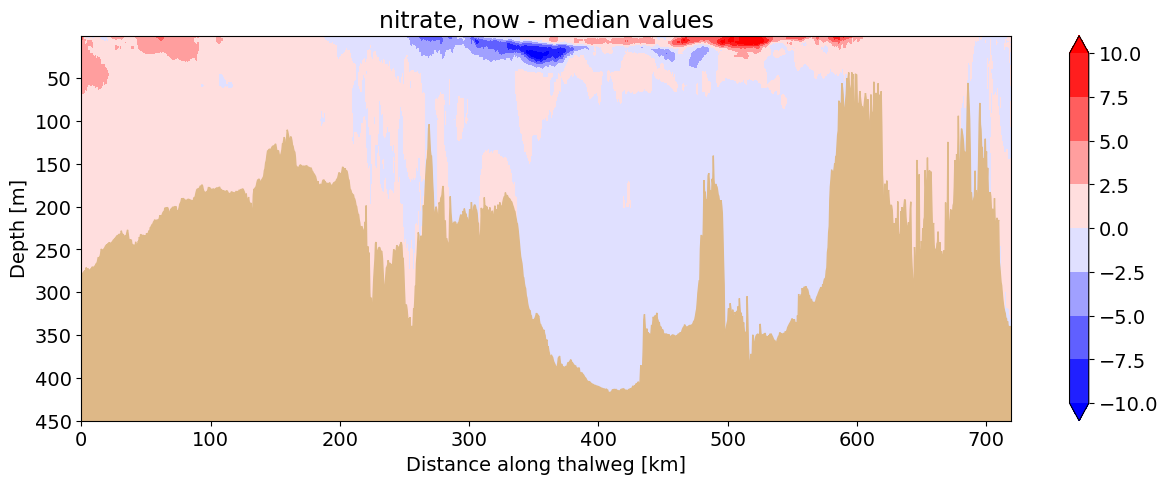

In [67]:
tmedian_ano_values = mymask(np.median(thistory_ano, axis=0), np.arange(nz), 1, tmask, step=1)
contour_plot(kf_ano, tnow_ano.values, tmedian_ano_values, scale=10)

In [68]:
nz, ny, nx = 40, 898, 398
thistory_ano = np.zeros((yearrange[1] - yearrange[0] + 1, nz, ny, nx))
tnow_ano = np.zeros_like(thistory_ano[0])
kf_ano = 0
tnow_ano = get_tnow(kf_ano, fields[kf_ano], tnow_ano)
thistory_ano = get_thistory(kf_ano, fields[kf_ano], thistory_ano)

2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025


/ocean/sallen/allen/research/Meopar/tools/SalishSeaTools/salishsea_tools/visualisations.py:256: UserWarning: Warning: converting a masked element to nan.
  newvar[level, i] = variable[level - 1, i]


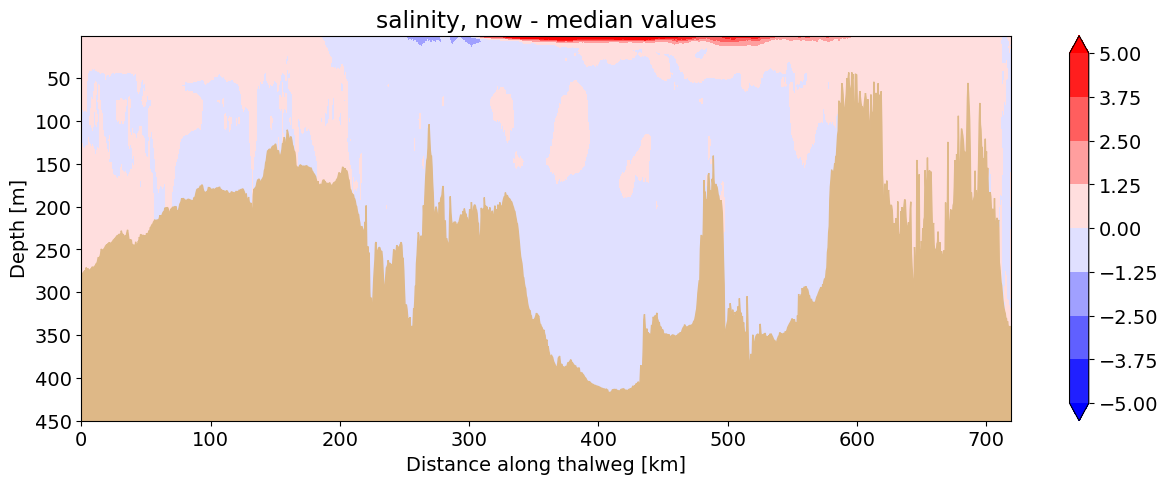

In [69]:
tmedian_ano_values = mymask(np.median(thistory_ano, axis=0), np.arange(nz), 1, tmask, step=1)
contour_plot(kf_ano, tnow_ano.values, tmedian_ano_values, scale=5)

In [70]:
nz, ny, nx = 40, 898, 398
thistory_ano = np.zeros((yearrange[1] - yearrange[0] + 1, nz, ny, nx))
tnow_ano = np.zeros_like(thistory_ano[0])
kf_ano = 4
tnow_ano = get_tnow(kf_ano, fields[kf_ano], tnow_ano)
thistory_ano = get_thistory(kf_ano, fields[kf_ano], thistory_ano)

2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025


/ocean/sallen/allen/research/Meopar/tools/SalishSeaTools/salishsea_tools/visualisations.py:256: UserWarning: Warning: converting a masked element to nan.
  newvar[level, i] = variable[level - 1, i]


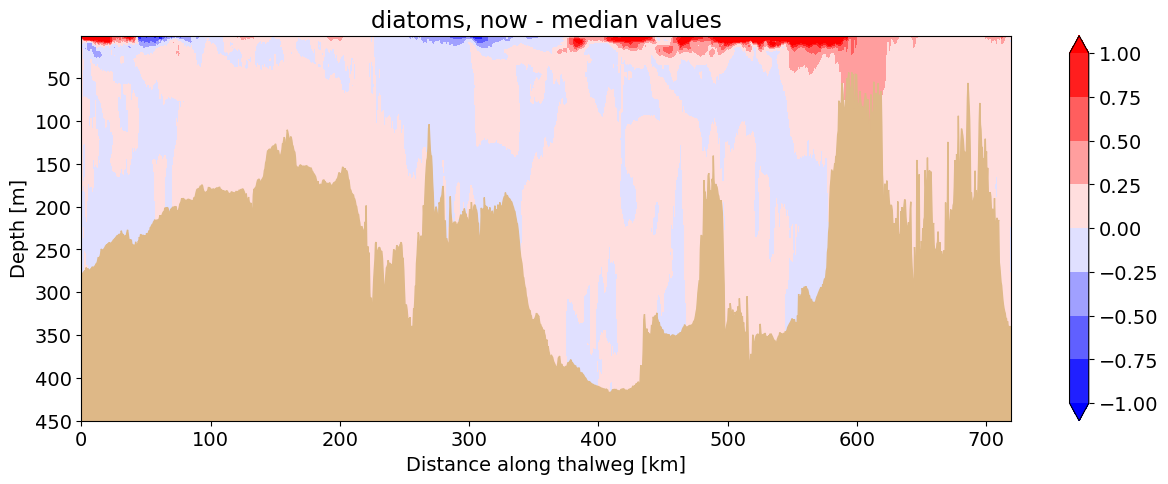

In [71]:
tmedian_ano_values = mymask(np.median(thistory_ano, axis=0), np.arange(nz), 1, tmask, step=1)
contour_plot(kf_ano, tnow_ano.values, tmedian_ano_values, scale=1)

In [72]:
nz, ny, nx = 40, 898, 398
thistory_ano = np.zeros((yearrange[1] - yearrange[0] + 1, nz, ny, nx))
tnow_ano = np.zeros_like(thistory_ano[0])
kf_ano = 5
tnow_ano = get_tnow(kf_ano, fields[kf_ano], tnow_ano)
thistory_ano = get_thistory(kf_ano, fields[kf_ano], thistory_ano)

2007
2008
2009
2010
2011
2012
2013
2014
2015
2016
2017
2018
2019
2020
2021
2022
2023
2024
2025


/ocean/sallen/allen/research/Meopar/tools/SalishSeaTools/salishsea_tools/visualisations.py:256: UserWarning: Warning: converting a masked element to nan.
  newvar[level, i] = variable[level - 1, i]


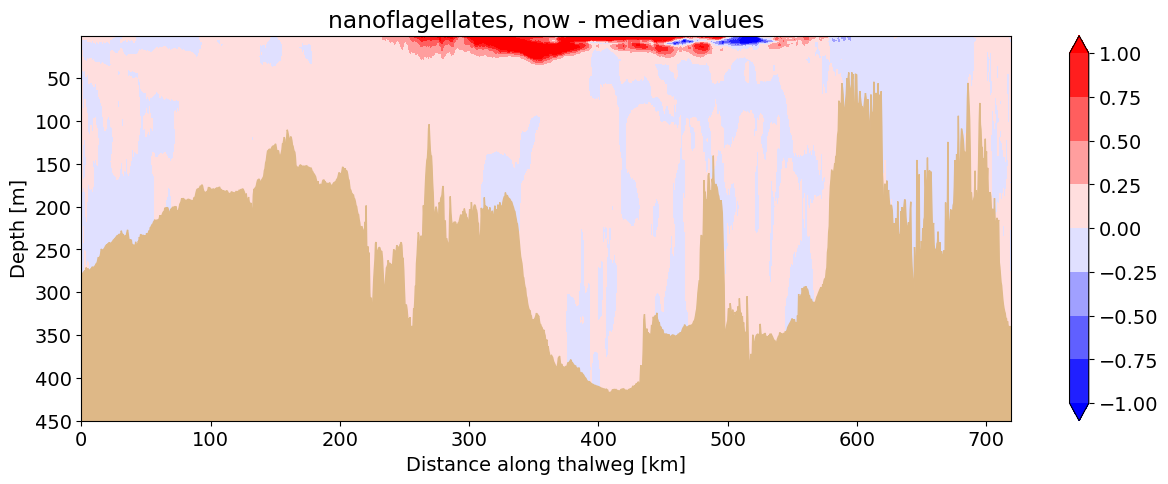

In [73]:
tmedian_ano_values = mymask(np.median(thistory_ano, axis=0), np.arange(nz), 1, tmask, step=1)
contour_plot(kf_ano, tnow_ano.values, tmedian_ano_values, scale=1)